In [56]:
%reload_ext autoreload
from functions_v2 import *

In [58]:
from tqdm import tqdm

In [6]:
import networkx as nx
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt

In [8]:
edges, n_vertices, edge_weights = load_graph("../summer-project/power-US-Grid.mtx")

✓ Loaded: ../summer-project/power-US-Grid.mtx
  Vertices : 4941
  Edges    : 6594
  Weighted : no



In [10]:
# Paper version
#visualize_graph_2d(edges, n_vertices, title="US Power Grid Network")


KeyboardInterrupt



In [12]:
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 4941 x 4941
  Degree range: [1, 19]
  Non-zeros in L: 18129



In [14]:
lambda_min = compute_lambda_min(L, D)
L_sigma    = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

✓ lambda_min = 0.000271
  (eigenvalues found: [0.         0.00027102])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)



In [16]:
# set seed for reproducibility
np.random.seed(42)

# run phase 3
u, B, cho_cache = run_phase3(L_sigma, lambda_min, edges, n_vertices)

✓ Phase 3 complete: correlated field u generated
  u range: [-0.1054, 0.1071]



In [34]:
k = compute_permeability(u, edges, edge_weights)

In [24]:
G_nx_power = nx.Graph()
G_nx_power.add_nodes_from(range(n_vertices))
G_nx_power.add_edges_from(edges)
print(f"NetworkX graph built: {G_nx_power.number_of_nodes()} nodes, {G_nx_power.number_of_edges()} edges")

NetworkX graph built: 4941 nodes, 6594 edges


In [32]:
def find_diameter_endpoints(G_nx, n_sample=5):
    """
    Find approximate diameter endpoints using double BFS.
    
    Step 1: Start from arbitrary vertex, find furthest vertex v
    Step 2: From v, find furthest vertex w  
    Step 3: v and w are approximate diameter endpoints
    
    n_sample: run from multiple start points and pick best pair
    """
    best_dist = 0
    best_v, best_w = None, None
    
    # sample a few starting points for robustness
    start_nodes = list(G_nx.nodes())[:n_sample]
    
    for start in start_nodes:
        # first BFS
        lengths = nx.single_source_shortest_path_length(G_nx, start)
        v = max(lengths, key=lengths.get)
        
        # second BFS from v
        lengths_v = nx.single_source_shortest_path_length(G_nx, v)
        w = max(lengths_v, key=lengths_v.get)
        dist = lengths_v[w]
        
        if dist > best_dist:
            best_dist = dist
            best_v, best_w = v, w
    
    return best_v, best_w, best_dist


# find diameter endpoints
v, w, diameter = find_diameter_endpoints(G_nx_power)
print(f"Diameter endpoints: vertex {v} and vertex {w}")
print(f"Shortest path between them: {diameter} hops")

# define gamma_in and gamma_out as k-hop neighborhoods
k_hop = 4  # include vertices within k hops of each endpoint

gamma_in  = set([v]) | set(nx.single_source_shortest_path_length(
                            G_nx_power, v, cutoff=k_hop).keys())
gamma_out = set([w]) | set(nx.single_source_shortest_path_length(
                            G_nx_power, w, cutoff=k_hop).keys())

# remove overlap before converting to list
gamma_in  = gamma_in  - gamma_out
gamma_out = gamma_out - gamma_in

# now convert to list
gamma_in  = list(gamma_in)
gamma_out = list(gamma_out)

print(f"\ngamma_in  : {len(gamma_in)} vertices (neighborhood of vertex {v})")
print(f"gamma_out : {len(gamma_out)} vertices (neighborhood of vertex {w})")
print(f"Flow must travel ~{diameter} hops from inlet to outlet")

Diameter endpoints: vertex 4349 and vertex 3495
Shortest path between them: 46 hops

gamma_in  : 23 vertices (neighborhood of vertex 4349)
gamma_out : 14 vertices (neighborhood of vertex 3495)
Flow must travel ~46 hops from inlet to outlet


In [ ]:
# degrees_arr = A.sum(axis=1)

# # gamma_in = top 5 highest degree nodes (most connected brain regions — processing hubs)
# # gamma_out = top 5 lowest degree nodes (least connected — peripheral regions)
# gamma_in  = list(np.argsort(degrees_arr)[-5:])
# gamma_out = list(np.argsort(degrees_arr)[:5])

# print(f"gamma_in  (hub regions)       : {gamma_in}")
# print(f"gamma_out (peripheral regions): {gamma_out}")
# print(f"  inlet degrees : {[int(degrees_arr[v]) for v in gamma_in]}")
# print(f"  outlet degrees: {[int(degrees_arr[v]) for v in gamma_out]}")

In [36]:
# weighted laplacian 
L_k = build_weighted_laplacian(edges, n_vertices, k)

In [38]:
p  = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)

In [60]:
np.random.seed(42)
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None,
                          N=1500, use_amg=False)

Monte Carlo:   0%|          | 0/1500 [00:00<?, ?sample/s]


✓ Done — 1500 samples
  Mean Q : 0.152135
  Std Q  : 0.001508



=== Monte Carlo Results ===
  Samples : 1500
  Mean Q  : 0.152135
  Std Q   : 0.001508
  Var Q   : 0.000002
  Min Q   : 0.147350
  Max Q   : 0.157552
Saved as uspowergrid_phase7.png


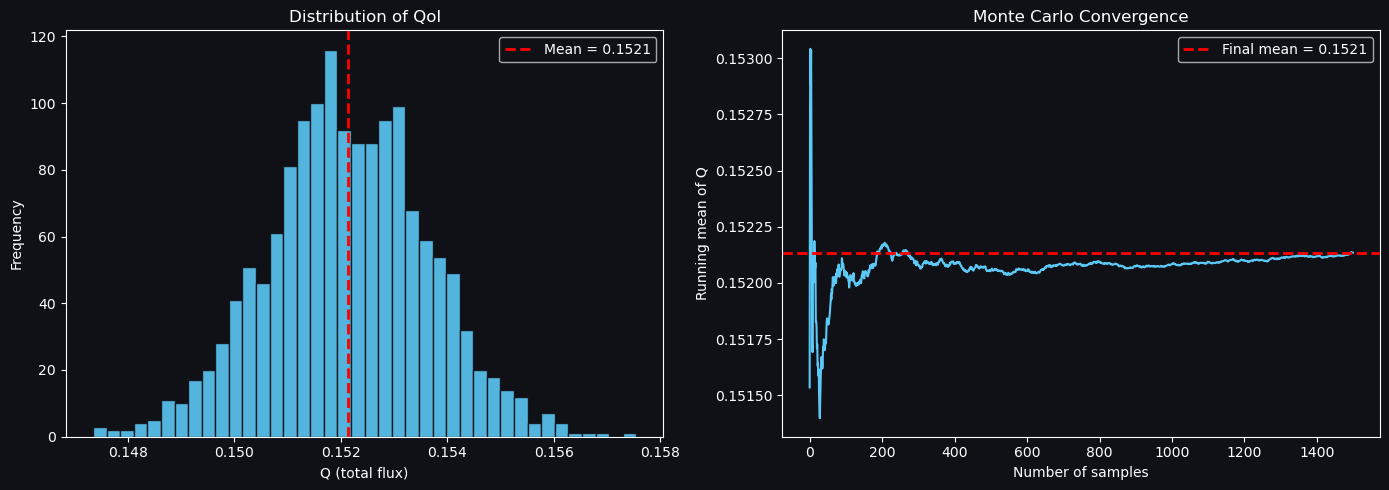

In [62]:
analyze_qoi(Q_samples, save_as="uspowergrid_phase7.png" )

# Effective solvers

In [ ]:
!pip install pyamg

In [ ]:
import time

# spsolve
t1 = time.time()
p_test = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)
print(f"spsolve: {time.time()-t1:.3f}s")

# AMG
t2 = time.time()
p_test = solve_darcy_amg(L_k, n_vertices, gamma_in, gamma_out)
print(f"AMG + PCG: {time.time()-t2:.3f}s")

In [ ]:
def find_diameter_endpoints(G_nx, n_sample=5):
    """
    Find approximate diameter endpoints using double BFS.
    
    Step 1: Start from arbitrary vertex, find furthest vertex v
    Step 2: From v, find furthest vertex w  
    Step 3: v and w are approximate diameter endpoints
    
    n_sample: run from multiple start points and pick best pair
    """
    best_dist = 0
    best_v, best_w = None, None
    
    # sample a few starting points for robustness
    start_nodes = list(G_nx.nodes())[:n_sample]
    
    for start in start_nodes:
        # first BFS
        lengths = nx.single_source_shortest_path_length(G_nx, start)
        v = max(lengths, key=lengths.get)
        
        # second BFS from v
        lengths_v = nx.single_source_shortest_path_length(G_nx, v)
        w = max(lengths_v, key=lengths_v.get)
        dist = lengths_v[w]
        
        if dist > best_dist:
            best_dist = dist
            best_v, best_w = v, w
    
    return best_v, best_w, best_dist


# find diameter endpoints
v, w, diameter = find_diameter_endpoints(G_nx_power)
print(f"Diameter endpoints: vertex {v} and vertex {w}")
print(f"Shortest path between them: {diameter} hops")

# define gamma_in and gamma_out as k-hop neighborhoods
k = 2  # include vertices within k hops of each endpoint

gamma_in  = set([v]) | set(nx.single_source_shortest_path_length(
                            G_nx_power, v, cutoff=k).keys())
gamma_out = set([w]) | set(nx.single_source_shortest_path_length(
                            G_nx_power, w, cutoff=k).keys())

# remove overlap before converting to list
gamma_in  = gamma_in  - gamma_out
gamma_out = gamma_out - gamma_in

# now convert to list
gamma_in  = list(gamma_in)
gamma_out = list(gamma_out)

print(f"\ngamma_in  : {len(gamma_in)} vertices (neighborhood of vertex {v})")
print(f"gamma_out : {len(gamma_out)} vertices (neighborhood of vertex {w})")
print(f"Flow must travel ~{diameter} hops from inlet to outlet")

# community detection

In [ ]:
# build networkx graph for power grid
G_nx_power = nx.Graph()
G_nx_power.add_nodes_from(range(n_vertices))
G_nx_power.add_edges_from(edges)

# use greedy modularity — power grid is 4941 nodes, should be fast enough
communities_power = list(nx.community.greedy_modularity_communities(G_nx_power))

print(f"Number of communities: {len(communities_power)}")
for i, c in enumerate(communities_power):
    print(f"  Community {i}: {len(c)} vertices, "
          f"avg degree = {np.mean([dict(G_nx_power.degree())[v] for v in c]):.2f}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# assign a color to each community
cmap = cm.get_cmap('tab20', len(communities_power))
node_colors = {}
for i, c in enumerate(communities_power):
    for v in c:
        node_colors[v] = cmap(i)

color_list = [node_colors[v] for v in G_nx_power.nodes()]
pos = nx.spring_layout(G_nx_power, seed=42, k=0.5)

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

nx.draw_networkx_edges(G_nx_power, pos, ax=ax, edge_color='white',
                       width=0.3, alpha=0.15)
nx.draw_networkx_nodes(G_nx_power, pos, ax=ax, node_color=color_list,
                       node_size=30, alpha=0.9)

ax.set_title(f'Community Structure — US Power Grid ({len(communities_power)} communities)',
             color='white', fontsize=14)
ax.axis('off')
plt.savefig('power_grid_communities.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

In [ ]:
import networkx as nx
from scipy.sparse.csgraph import shortest_path
from scipy.sparse import csr_matrix

def find_diameter_endpoints(G_nx, n_sample=5):
    """
    Find approximate diameter endpoints using double BFS.
    
    Step 1: Start from arbitrary vertex, find furthest vertex v
    Step 2: From v, find furthest vertex w  
    Step 3: v and w are approximate diameter endpoints
    
    n_sample: run from multiple start points and pick best pair
    """
    best_dist = 0
    best_v, best_w = None, None
    
    # sample a few starting points for robustness
    start_nodes = list(G_nx.nodes())[:n_sample]
    
    for start in start_nodes:
        # first BFS
        lengths = nx.single_source_shortest_path_length(G_nx, start)
        v = max(lengths, key=lengths.get)
        
        # second BFS from v
        lengths_v = nx.single_source_shortest_path_length(G_nx, v)
        w = max(lengths_v, key=lengths_v.get)
        dist = lengths_v[w]
        
        if dist > best_dist:
            best_dist = dist
            best_v, best_w = v, w
    
    return best_v, best_w, best_dist


# find diameter endpoints
v, w, diameter = find_diameter_endpoints(G_nx_power)
print(f"Diameter endpoints: vertex {v} and vertex {w}")
print(f"Shortest path between them: {diameter} hops")

# define gamma_in and gamma_out as k-hop neighborhoods
k = 2  # include vertices within k hops of each endpoint

gamma_in  = set([v]) | set(nx.single_source_shortest_path_length(
                            G_nx_power, v, cutoff=k).keys())
gamma_out = set([w]) | set(nx.single_source_shortest_path_length(
                            G_nx_power, w, cutoff=k).keys())

# remove overlap before converting to list
gamma_in  = gamma_in  - gamma_out
gamma_out = gamma_out - gamma_in

# now convert to list
gamma_in  = list(gamma_in)
gamma_out = list(gamma_out)

print(f"\ngamma_in  : {len(gamma_in)} vertices (neighborhood of vertex {v})")
print(f"gamma_out : {len(gamma_out)} vertices (neighborhood of vertex {w})")
print(f"Flow must travel ~{diameter} hops from inlet to outlet")

In [ ]:
for k in [1, 2, 3, 4, 5]:
    gin  = set(nx.single_source_shortest_path_length(G_nx_power, v, cutoff=k).keys())
    gout = set(nx.single_source_shortest_path_length(G_nx_power, w, cutoff=k).keys())
    gin  = gin - gout
    gout = gout - gin
    print(f"k={k}: gamma_in={len(gin)}, gamma_out={len(gout)}")

In [ ]:
k = 4
gamma_in  = set(nx.single_source_shortest_path_length(G_nx_power, v, cutoff=k).keys())
gamma_out = set(nx.single_source_shortest_path_length(G_nx_power, w, cutoff=k).keys())
gamma_in  = gamma_in - gamma_out
gamma_out = gamma_out - gamma_in
gamma_in  = list(gamma_in)
gamma_out = list(gamma_out)

print(f"gamma_in  : {len(gamma_in)} vertices")
print(f"gamma_out : {len(gamma_out)} vertices")

In [ ]:
from functions_v2 import *

In [ ]:
np.random.seed(42)
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                                   gamma_in, gamma_out, edge_weights=None,
                                   N=2000, use_amg=False)
analyze_qoi(Q_samples, save_as="uspowergrid_phase7-diameter-approach- 2000 samples.png")